In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load data
df = pd.read_csv('../data/raw/customer_data.csv')

print("=" * 60)
print("RFM ANALYSIS - CUSTOMER SEGMENTATION")
print("=" * 60)

# Calculate RFM metrics
# R = Recency (days since last purchase)
# F = Frequency (number of purchases)
# M = Monetary (total spent)

rfm = pd.DataFrame()
rfm['customer_id'] = df['customer_id']
rfm['recency'] = df['last_purchase_days_ago']
rfm['frequency'] = df['total_purchases']
rfm['monetary'] = df['total_spent']

print("\nRFM Metrics (First 10 customers):")
print(rfm.head(10))
print(f"\nRFM Statistics:")
print(rfm[['recency', 'frequency', 'monetary']].describe())

RFM ANALYSIS - CUSTOMER SEGMENTATION

RFM Metrics (First 10 customers):
   customer_id  recency  frequency  monetary
0            1      313         19      2476
1            2       49         30      3109
2            3      118          7      3093
3            4       54         10      1062
4            5      138         41      3732
5            6       53         32      1927
6            7       44         34      1713
7            8      303         28      1740
8            9       53         15      2316
9           10       74         30      4412

RFM Statistics:
           recency    frequency  monetary
count  1000.000000  1000.000000  1000.000
mean    180.694000    24.363000  2505.241
std     105.520382    13.977718  1368.109
min       1.000000     1.000000   106.000
25%      89.750000    12.000000  1340.250
50%     175.000000    24.000000  2422.000
75%     274.250000    36.000000  3729.250
max     364.000000    49.000000  4997.000


In [2]:
# Create RFM Score (1-5 scale)
# Recency: Lower is better (recent purchases = higher score)
# Frequency: Higher is better (more purchases = higher score)
# Monetary: Higher is better (more spent = higher score)

rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# Combine scores
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print("\nRFM Scores (First 15 customers):")
print(rfm[['customer_id', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'RFM_Score']].head(15))


RFM Scores (First 15 customers):
    customer_id  recency  frequency  monetary R_score F_score M_score  \
0             1      313         19      2476       1       2       3   
1             2       49         30      3109       5       4       4   
2             3      118          7      3093       4       1       4   
3             4       54         10      1062       5       1       1   
4             5      138         41      3732       4       5       4   
5             6       53         32      1927       5       4       2   
6             7       44         34      1713       5       4       2   
7             8      303         28      1740       1       3       2   
8             9       53         15      2316       5       2       3   
9            10       74         30      4412       4       4       5   
10           11       46         37       477       5       4       1   
11           12       13         29      4314       5       3       5   
12           13  

In [3]:
# Define customer segments based on RFM scores
def segment_customer(rfm_score):
    score_int = int(rfm_score)
    
    if score_int >= 555:
        return 'Champions'  # Best customers
    elif score_int >= 444:
        return 'Loyal Customers'
    elif score_int >= 333:
        return 'At Risk'
    elif score_int >= 222:
        return 'Need Attention'
    else:
        return 'Lost'  # Worst customers

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

print("\n" + "=" * 60)
print("CUSTOMER SEGMENTS")
print("=" * 60)

segment_counts = rfm['Segment'].value_counts()
print("\nSegment Distribution:")
print(segment_counts)

print("\nSegment Percentages:")
print((segment_counts / len(rfm) * 100).round(2))

print("\nSegment Analysis:")
for segment in ['Champions', 'Loyal Customers', 'At Risk', 'Need Attention', 'Lost']:
    segment_data = rfm[rfm['Segment'] == segment]
    if len(segment_data) > 0:
        print(f"\n{segment}:")
        print(f"  Count: {len(segment_data)}")
        print(f"  Avg Recency: {segment_data['recency'].mean():.1f} days")
        print(f"  Avg Frequency: {segment_data['frequency'].mean():.1f} purchases")
        print(f"  Avg Monetary: ${segment_data['monetary'].mean():.2f}")


CUSTOMER SEGMENTS

Segment Distribution:
Segment
Loyal Customers    249
Need Attention     248
At Risk            247
Lost               246
Champions           10
Name: count, dtype: int64

Segment Percentages:
Segment
Loyal Customers    24.9
Need Attention     24.8
At Risk            24.7
Lost               24.6
Champions           1.0
Name: count, dtype: float64

Segment Analysis:

Champions:
  Count: 10
  Avg Recency: 33.1 days
  Avg Frequency: 43.1 purchases
  Avg Monetary: $4437.90

Loyal Customers:
  Count: 249
  Avg Recency: 54.5 days
  Avg Frequency: 28.4 purchases
  Avg Monetary: $2457.95

At Risk:
  Count: 247
  Avg Recency: 136.8 days
  Avg Frequency: 24.7 purchases
  Avg Monetary: $2494.93

Need Attention:
  Count: 248
  Avg Recency: 223.2 days
  Avg Frequency: 23.1 purchases
  Avg Monetary: $2617.00

Lost:
  Count: 246
  Avg Recency: 315.5 days
  Avg Frequency: 20.5 purchases
  Avg Monetary: $2372.23


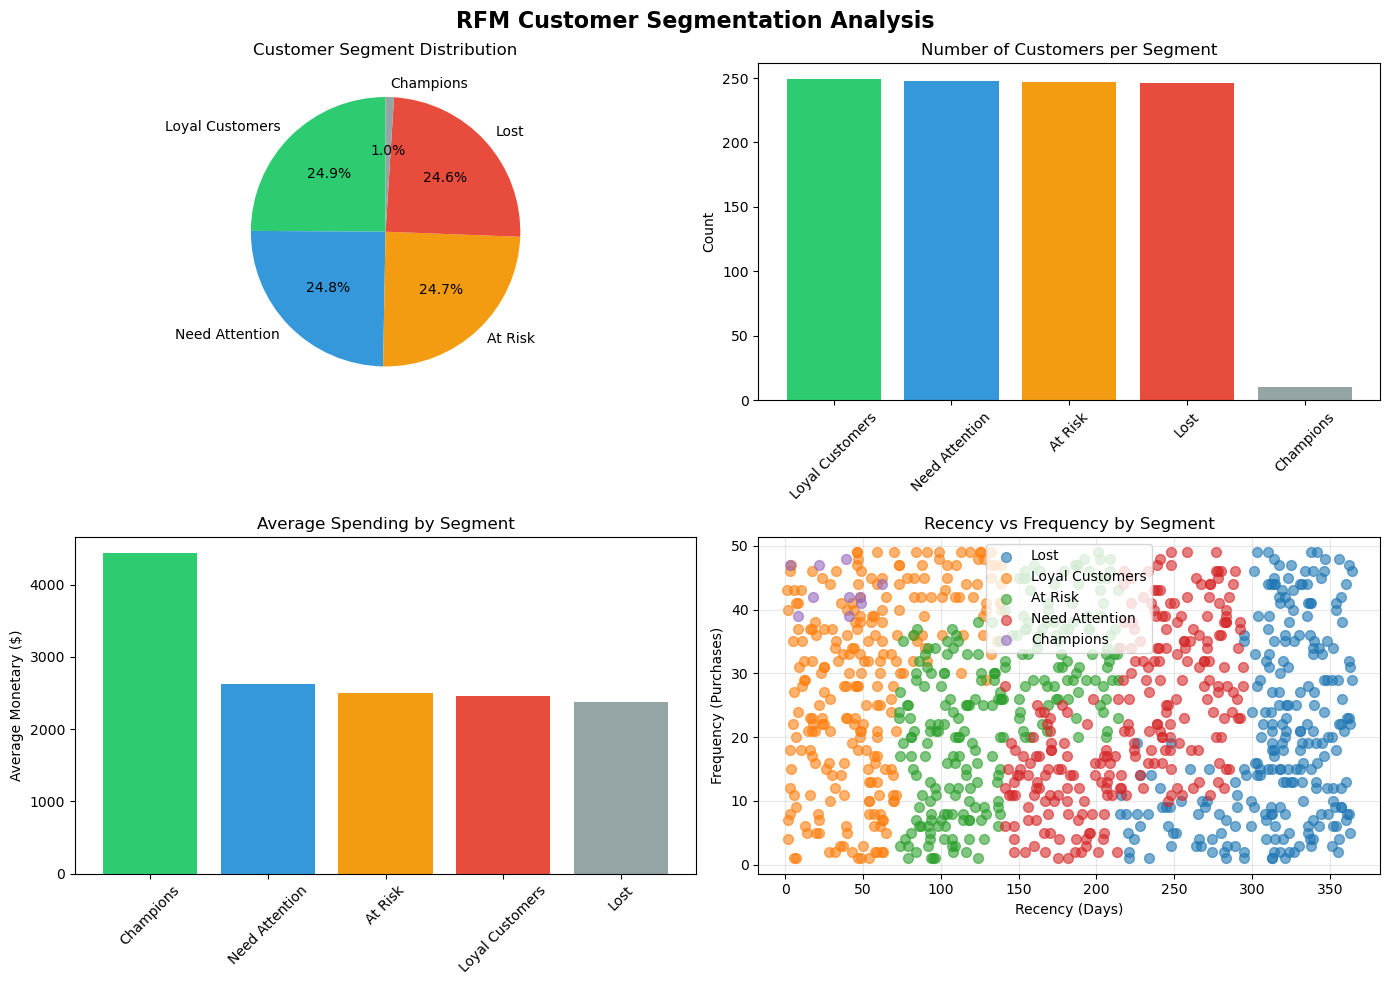

Visualizations created!


In [4]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RFM Customer Segmentation Analysis', fontsize=16, fontweight='bold')

# 1. Segment Distribution (Pie Chart)
segment_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
axes[0, 0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', 
               colors=colors, startangle=90)
axes[0, 0].set_title('Customer Segment Distribution')

# 2. Segment Bar Chart
axes[0, 1].bar(segment_counts.index, segment_counts.values, color=colors)
axes[0, 1].set_title('Number of Customers per Segment')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Average Monetary by Segment
segment_monetary = rfm.groupby('Segment')['monetary'].mean().sort_values(ascending=False)
axes[1, 0].bar(segment_monetary.index, segment_monetary.values, color=colors)
axes[1, 0].set_title('Average Spending by Segment')
axes[1, 0].set_ylabel('Average Monetary ($)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Recency vs Frequency by Segment
for segment in rfm['Segment'].unique():
    segment_data = rfm[rfm['Segment'] == segment]
    axes[1, 1].scatter(segment_data['recency'], segment_data['frequency'], 
                       label=segment, alpha=0.6, s=50)
axes[1, 1].set_title('Recency vs Frequency by Segment')
axes[1, 1].set_xlabel('Recency (Days)')
axes[1, 1].set_ylabel('Frequency (Purchases)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizations created!")

In [5]:
# Save the RFM analysis results
rfm_output = rfm.copy()
rfm_output.to_csv('../data/processed/rfm_segmentation.csv', index=False)

print("\n" + "=" * 60)
print("✅ RFM Analysis Complete!")
print("=" * 60)
print(f"Segmented data saved to: data/processed/rfm_segmentation.csv")
print(f"\nTotal Customers Analyzed: {len(rfm)}")
print(f"Segments Created: {rfm['Segment'].nunique()}")


✅ RFM Analysis Complete!
Segmented data saved to: data/processed/rfm_segmentation.csv

Total Customers Analyzed: 1000
Segments Created: 5
